### implementation for each question where MM-algorithm and Weibull distribution is done in python

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [12]:
class MM_Weibull:
    """
    MM/Fixed-Point Algorithm for 2-Parameter Weibull MLE
    
    Update formula from notes written in question1:
    1/kappa_new = [sum(x_i^kappa * ln(x_i))] / [sum(x_i^kappa)] - (1/n) * sum(ln(x_i))

    """
    
    def __init__(self, data):
        self.data = np.asarray(data, dtype=float)
        self.n = len(self.data)
        self.sum_log_x = np.sum(np.log(self.data))
        self.mean_log_x = self.sum_log_x / self.n
        self.kappa_hat = None
        self.lambda_hat = None
        self.iterations_used = None
        
    def log_likelihood(self, kappa, lam):
            term1 = self.n * np.log(kappa)
            term2 = -self.n * kappa * np.log(lam)
            term3 = (kappa - 1) * self.sum_log_x
            term4 = -np.sum(np.power(self.data / lam, kappa))
            return term1 + term2 + term3 + term4
    
    def _update_kappa(self, kappa_current):
        numerator = np.sum(np.power(self.data, kappa_current) * np.log(self.data))
        denominator = np.sum(np.power(self.data, kappa_current))
        inverse_kappa_new = numerator / denominator - self.mean_log_x
        return 1.0 / inverse_kappa_new
    
    def _estimate_lambda(self, kappa):
        mean_x_power_k = np.mean(np.power(self.data, kappa))
        return np.power(mean_x_power_k, 1.0 / kappa)
    
    def fit(self, kappa_init=1.0, max_iter=100, tol=1e-4, verbose=False):
        kappa_current = kappa_init
        self.iterations_used = 0
        
        if verbose:
            print("Iteration    kappa        lambda       delta_kappa    LogLikelihood")
            print("-" * 70)
        
        for iteration in range(max_iter):
            lambda_current = self._estimate_lambda(kappa_current)
            kappa_new = self._update_kappa(kappa_current)
            delta = abs(kappa_new - kappa_current)
            ll = self.log_likelihood(kappa_new, lambda_current)
            
            if verbose:
                print(f"{iteration:<10} {kappa_new:<10.4f} {lambda_current:<10.4f} {delta:<12.6e} {ll:<15.4f}")
            
            if delta < tol:
                self.kappa_hat = kappa_new
                self.lambda_hat = lambda_current
                self.iterations_used = iteration + 1
                break
            
            kappa_current = kappa_new
        
        self.kappa_hat = kappa_new
        self.lambda_hat = self._estimate_lambda(kappa_new)
        
        return self.kappa_hat, self.lambda_hat
    
    def get_params(self):
        return (self.kappa_hat, self.lambda_hat)

In [13]:
#question 2 where i implement basic use of  the mm algorithm
def question2():
    """
    Question 2: Implement algorithm for the 2 parameter weibull distribution.
    
    we put two known parameters nd make data for the weibull Distribution. 
    The mm algorithim is used to estimate these parameters and results are printed
    """
    print("=" * 70)
    print("QUESTION 2: MM ALGORITHM IMPLEMENTATION")
    print("=" * 70)
    
    np.random.seed(117)
    kappa_true = 3.5
    lambda_true = 1.55
    n_samples = 200
    data = lambda_true * np.random.weibull(kappa_true, size=n_samples)
    
    print(f"Parameters: kappa_true={kappa_true}, lambda_true={lambda_true}")
    print("-" * 70)
    
    model = MM_Weibull(data)
    kappa_hat, lambda_hat = model.fit(kappa_init=1.0, verbose=True)
    
    print("")
    print("-" * 70)
    print(f"RESULTS: for kappa_true={kappa_true}, lambda_true={lambda_true}")
    print("-" * 70)
    print(f"kappa Estimated Value: {kappa_hat:.4f}")
    print(f"lambda Estimated Value: {lambda_hat:.4f}")
    print(f"kappa Relative Error : {(kappa_hat-kappa_true)/kappa_true*100:+.2f}%")
    print(f"lambda Relative Error: {(lambda_hat-lambda_true)/lambda_true*100:+.2f}%")
    print("-" * 70)

In [14]:
#Here is question 4 part 1
def question4_simulation1():
    """
    Question4: Simulation 1: Sample Size
    
    Does estimation accuracy depend on the sample size given?
    I noticed when picking n, that larger samples give better results,
    so I wanted to test this with various sample sizes.
    """
    print("\n" + "=" * 70)
    print("QUESTION 4: SIMULATION 1 - Sample Size")
    print("=" * 70)
    
    print("\nHow does the estimation accuracy change with sample size?\n")
    
    kappa_true = 3.5
    lambda_true = 1.55

    sample_sizes = [50, 100, 200, 500, 1000, 2000]# Sample sizes to test
    print(f"Parameters: kappa_true={kappa_true}, lambda_true={lambda_true}")
    print("n    kappa_hat   kappa_error   lambda_hat   lambda_error")
    print("-" * 75)
    
    for n in sample_sizes:
        np.random.seed(117)
        data = lambda_true * np.random.weibull(kappa_true, size=n)
        model = MM_Weibull(data)
        kappa_hat, lambda_hat = model.fit(verbose=False)
        
        kappa_error = (kappa_hat - kappa_true) / kappa_true * 100
        lambda_error = (lambda_hat - lambda_true) / lambda_true * 100

        
        print(f"{n:<8} {kappa_hat:<11.4f} {kappa_error:<11.2f} {lambda_hat:<11.4f}  {lambda_error:<11.2f}")

In [15]:
#question 4 part 2 simulation
def question4_simulation2():
    """
    Simulation Study 2: Initialisation parameters
    
    How do different starting values affect the convergence of the algorithm?
    Can i pick some totally random numbers of different sizes to see if the algorithm can easily converge to the true vlaues?
    i took really small (near 0 at 0.001) and relativly large (100) values to see if the algorithm can still converge to the true values.
    """
    print("\n" + "=" * 70)
    print("QUESTION 4: SIMULATION STUDY 2 - Initialisation parameters")
    print("=" * 70)
    
    print("\nHow does the input guess values affect the convergence?\n")
    
    kappa_true = 3.5
    lambda_true = 1.55
    n_samples = 200
    
    initial_values = [0.001, 0.01, 0.5, 2.0, 15.78, 100.0] #guess values
    
    print(f"Parameters: kappa_true={kappa_true}, lambda_true={lambda_true}")
    print("init_kappa  final_kappa  final_lambda  delta_from_init  iterations_used")
    print("-" * 70)
    
    np.random.seed(117)
    data = lambda_true * np.random.weibull(kappa_true, size=n_samples)
    
    for kappa_init in initial_values:
        model = MM_Weibull(data)
        kappa_hat, lambda_hat = model.fit(kappa_init=kappa_init, verbose=False)
        
        iterations_used = model.iterations_used
        
        delta_from_init = abs(kappa_hat - kappa_init)
        
        print(f"{kappa_init:<11} {kappa_hat:<12.4f} {lambda_hat:<12.4f} {delta_from_init:<16.4f}  {iterations_used:<22}")
    print("=" * 70)

In [16]:
def question5(csv_filepath="/home/stefan_stringer/FinalSemester/Deep Learning/Advanced stat/Assignment/First one/earthquakes (2).csv"):
    """
    Question 5: Analysis showing Weibull vs Poisson comparison.
    I have seen earthquakes referenced for mix models etc, and saw when looking up Wiebull modeling, that it was used with earthquake data, and thought I would compare to a Poisson distribution.
    I pickd the earthquakes that were in Canterbury, New Zealand, where I am from, as I remember them still.
    I wanted to use this, to help get a better understanding for the weibull distribution, and how it can be used to model real world data.
    Waiting times are measured in hours, as it honestly felt like they were all the time after the main ones. The frequency was greater directly after the big two ones
    """
    print("=" * 70)
    print("QUESTION 5: EARTHQUAKE FREQUENCY ANALYSIS")
    print("=" * 70)
    
    df = pd.read_csv(csv_filepath)
    print(f"Loaded {len(df)} earthquakes")
    # Parse timestamps and sort
    df['origintime'] = pd.to_datetime(df['origintime'])

    df = df.sort_values('origintime').reset_index(drop=True)

    # Show time range
    start_time = df['origintime'].min()
    end_time = df['origintime'].max()

    print(f"Time period:{start_time} to {end_time}")
    print("-" * 70)

#times between the eatrhquakes
    times = (df['origintime'].sort_values().reset_index(drop=True))
    gaps = times.diff().dropna()
    waiting_times = (gaps.dt.total_seconds() / (60 * 60))
    waiting_times = (waiting_times[waiting_times > 0].to_numpy())

    print(f"Number of waiting times: {len(waiting_times)}")
    print(f"Mean waiting time: {waiting_times.mean():.3f} hours")
    print(f"Min waiting time: {waiting_times.min():.3f} hours")
    print(f"Max waiting time: {waiting_times.max():.3f} hours")
    print("-" * 70)

#Fitting for the weibull model

    weibull_model = MM_Weibull(waiting_times)
    kappa_hat, lambda_hat = weibull_model.fit(kappa_init=1.0, verbose=False)

    print("\nWeibull fit results:")
    print(f"  kappa (shape): {kappa_hat:.4f}")
    print(f"  lambda (scale): {lambda_hat:.4f} hours")
    print("-" * 70)

#fitting for the poisson model
    poisson_rate = (1.0 / np.mean(waiting_times))
    poisson_rate_per_day = (poisson_rate * 24)
    poisson_rate_per_year = (poisson_rate * 24 * 365)

    print("\nPoisson fit results:")
    print(f"  Rate (events per hour): {poisson_rate:.6f}")
    print(f"  Rate (events per day):{poisson_rate_per_day:.4f}")
    print(f"  Rate (events per year):{poisson_rate_per_year:.2f}")
    print("-" * 70)

#plotting time
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(waiting_times, bins=200, density=True, alpha=0.6, color='steelblue', edgecolor='black', label='Observed Data', zorder=3)

    t_vals = np.linspace(0.0001, 60, 200)
    weibull_pdf = ((kappa_hat / lambda_hat) * (t_vals / lambda_hat) ** (kappa_hat - 1) * np.exp(-((t_vals / lambda_hat) ** kappa_hat)))

    poisson_pdf = (poisson_rate * np.exp(-poisson_rate * t_vals))

    ax.plot(t_vals, weibull_pdf, 'r-', linewidth=2.5, label=f'Weibull fit (kappa={kappa_hat:.2f})', zorder=5)
    ax.plot(t_vals, poisson_pdf, 'g--', linewidth=2.0, label=(f'Poisson fit (rate={poisson_rate:.4f}/hour)'), zorder=5)
    ax.set_xlabel('Hours between earthquakes', fontsize=12)
    ax.set_ylabel('Probability Density', fontsize=12)
    ax.set_title('Canterbury Earthquake Frequency 2010-2012: Weibull vs Poisson Comparison', fontsize=14, fontweight='bold')
    ax.legend( fontsize=12)
    ax.grid(True)
    ax.set_xlim(left=0, right=36) #day and half #4 days
    ax.set_ylim(bottom=0,top=0.40)
    plt.tight_layout()
    plt.show()

### Here we have answers, as all code is handled above

In [17]:
question2()

QUESTION 2: MM ALGORITHM IMPLEMENTATION
Parameters: kappa_true=3.5, lambda_true=1.55
----------------------------------------------------------------------
Iteration    kappa        lambda       delta_kappa    LogLikelihood
----------------------------------------------------------------------
0          9.0584     1.4277     8.058419e+00 -1238.9936     
1          2.3335     1.7852     6.724913e+00 -158.1642      
2          4.7863     1.5158     2.452821e+00 -148.8460      
3          3.1391     1.6372     1.647178e+00 -125.3791      
4          3.9702     1.5603     8.310121e-01 -122.3024      
5          3.4693     1.6011     5.008630e-01 -120.6222      
6          3.7436     1.5771     2.742846e-01 -120.2158      
7          3.5847     1.5905     1.588663e-01 -120.0611      
8          3.6739     1.5828     8.917979e-02 -120.0157      
9          3.6229     1.5871     5.096773e-02 -120.0002      
10         3.6518     1.5846     2.883515e-02 -119.9954      
11         3.6354     1

In [18]:
question4_simulation1()


QUESTION 4: SIMULATION 1 - Sample Size

How does the estimation accuracy change with sample size?

Parameters: kappa_true=3.5, lambda_true=1.55
n    kappa_hat   kappa_error   lambda_hat   lambda_error
---------------------------------------------------------------------------
50       3.2582      -6.91       1.5761       1.68       
100      3.7857      8.16        1.6344       5.45       
200      3.6413      4.04        1.5855       2.29       
500      3.5681      1.95        1.5373       -0.82      
1000     3.5979      2.80        1.5430       -0.45      
2000     3.5428      1.22        1.5465       -0.23      


In [19]:
question4_simulation2()


QUESTION 4: SIMULATION STUDY 2 - Initialisation parameters

How does the input guess values affect the convergence?

Parameters: kappa_true=3.5, lambda_true=1.55
init_kappa  final_kappa  final_lambda  delta_from_init  iterations_used
----------------------------------------------------------------------
0.001       nan          nan          nan               0                     
0.01        3.6413       1.5855       3.6313            23                    
0.5         3.6413       1.5855       3.1413            22                    
2.0         3.6413       1.5855       1.6413            20                    
15.78       3.6413       1.5855       12.1387           21                    
100.0       3.6413       1.5855       96.3587           22                    


/tmp/ipykernel_117555/353147220.py:23: RuntimeWarning: overflow encountered in power
  term4 = -np.sum(np.power(self.data / lam, kappa))
/tmp/ipykernel_117555/353147220.py:33: RuntimeWarning: overflow encountered in power
  mean_x_power_k = np.mean(np.power(self.data, kappa))
/tmp/ipykernel_117555/353147220.py:27: RuntimeWarning: overflow encountered in power
  numerator = np.sum(np.power(self.data, kappa_current) * np.log(self.data))
/tmp/ipykernel_117555/353147220.py:28: RuntimeWarning: overflow encountered in power
  denominator = np.sum(np.power(self.data, kappa_current))
/tmp/ipykernel_117555/353147220.py:29: RuntimeWarning: invalid value encountered in scalar divide
  inverse_kappa_new = numerator / denominator - self.mean_log_x


QUESTION 5: EARTHQUAKE FREQUENCY ANALYSIS
Loaded 1947 earthquakes
Time period:2010-08-27 00:05:02.770000+00:00 to 2012-07-27 23:36:11.703000+00:00
----------------------------------------------------------------------
Number of waiting times: 1946
Mean waiting time: 8.645 hours
Min waiting time: 0.000 hours
Max waiting time: 311.540 hours
----------------------------------------------------------------------

Weibull fit results:
  kappa (shape): 0.3992
  lambda (scale): 2.4472 hours
----------------------------------------------------------------------

Poisson fit results:
  Rate (events per hour): 0.115671
  Rate (events per day):2.7761
  Rate (events per year):1013.28
----------------------------------------------------------------------


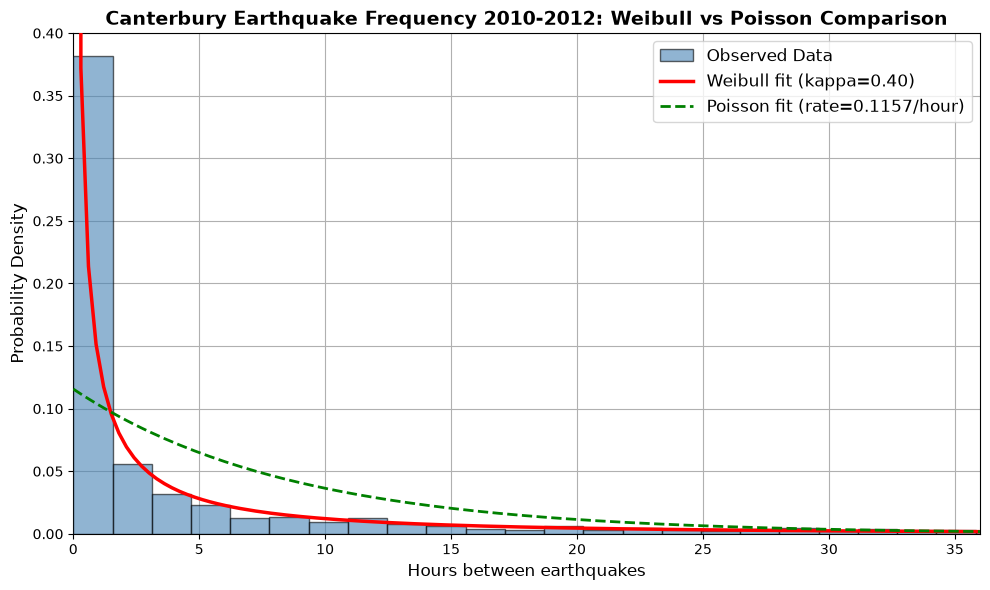

In [20]:
question5()